# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [15]:
df = pd.read_csv('data/nndb_flat.csv')
df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [17]:
df.describe()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,15467.757368,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,9221.428766,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,1001.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8695.250000,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,14273.000000,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,20050.750000,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,93600.000000,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

<Axes: >

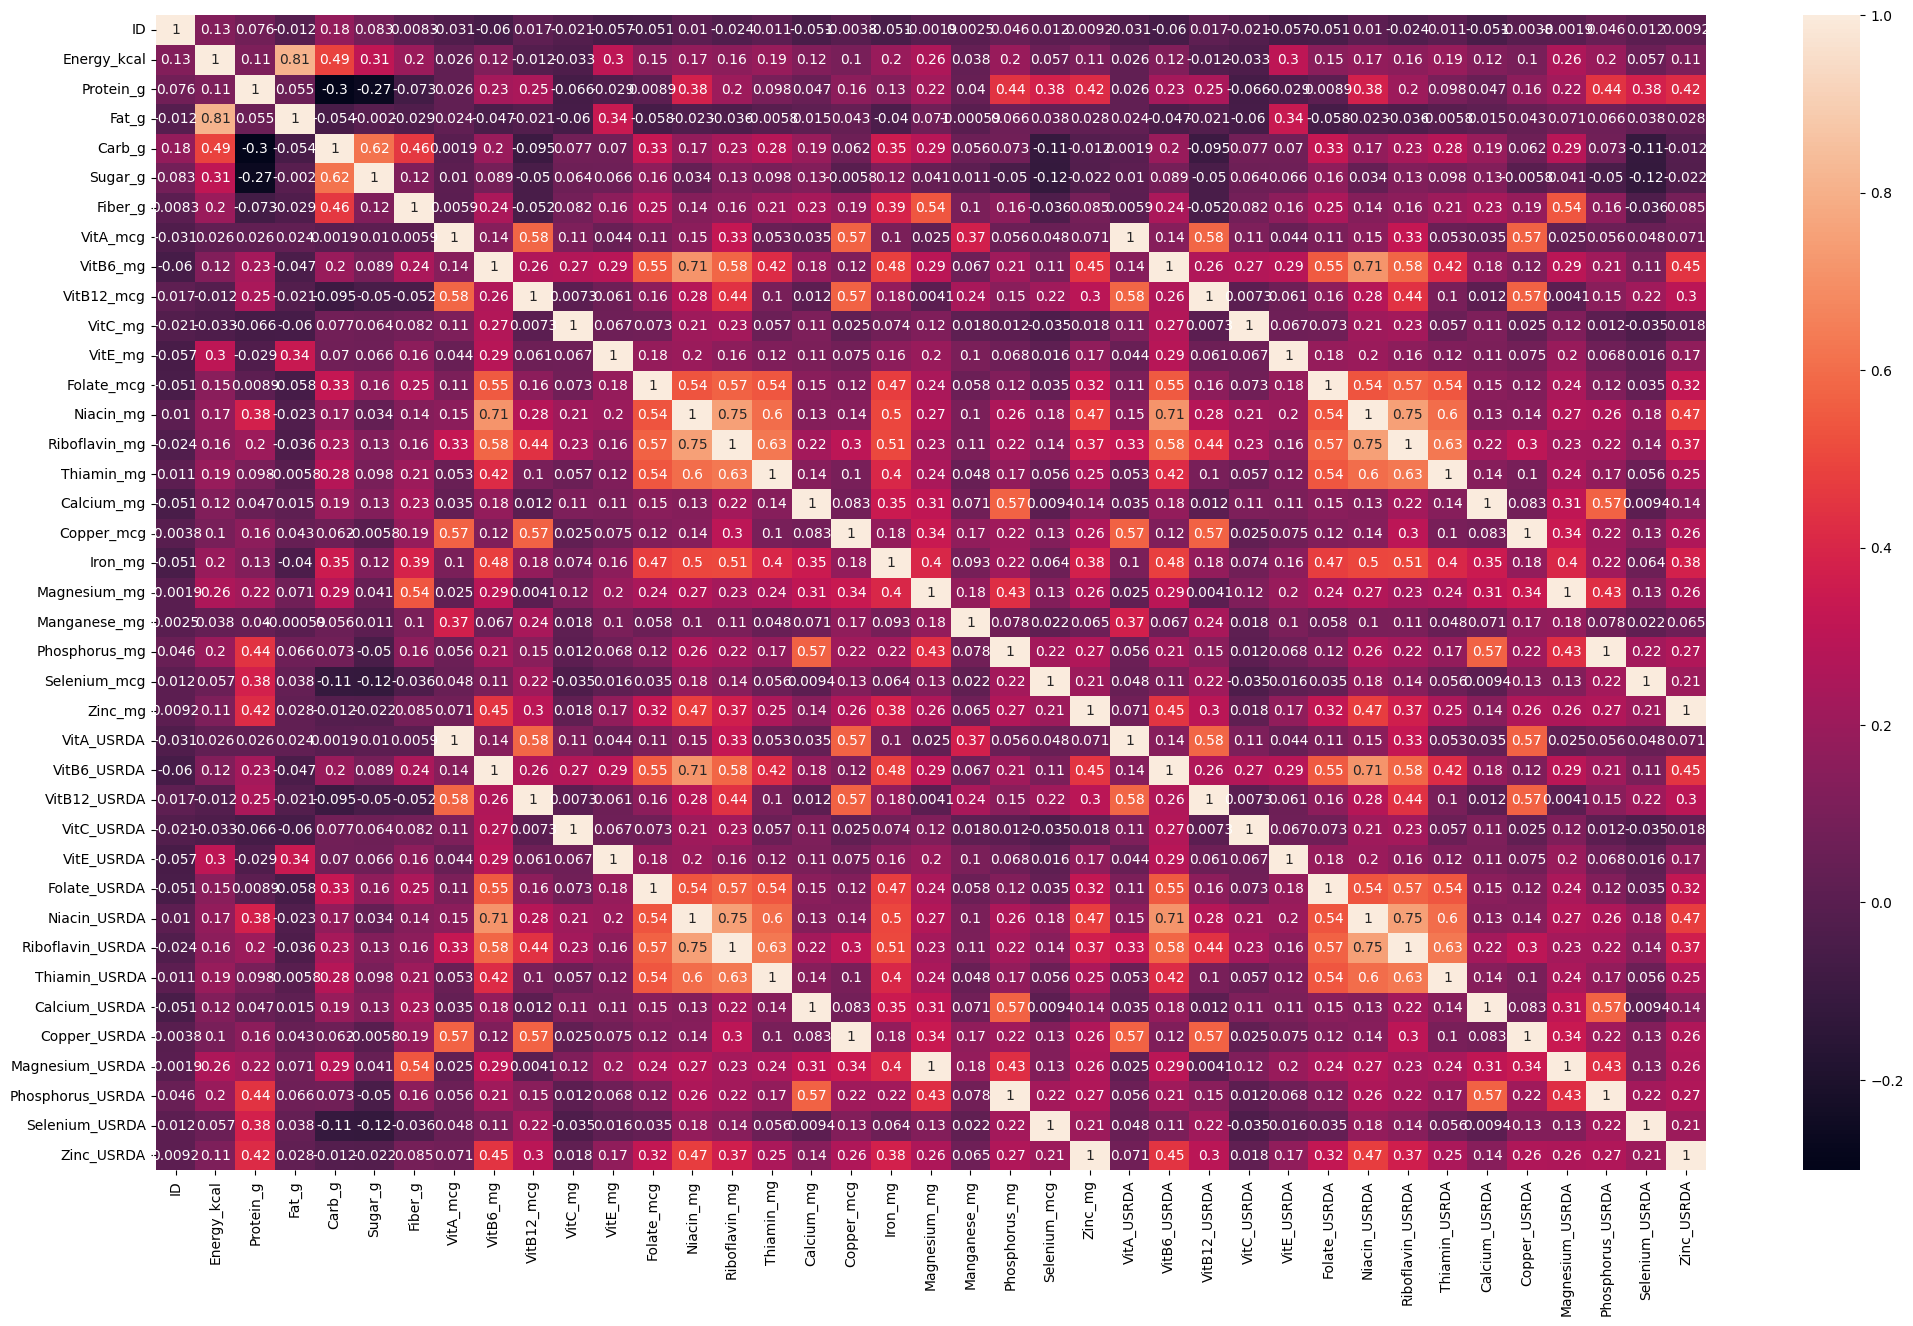

In [18]:
plt.figure(figsize=(25,15))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [19]:
df.columns[df.columns.str.contains("USRDA")]

Index(['VitA_USRDA', 'VitB6_USRDA', 'VitB12_USRDA', 'VitC_USRDA', 'VitE_USRDA',
       'Folate_USRDA', 'Niacin_USRDA', 'Riboflavin_USRDA', 'Thiamin_USRDA',
       'Calcium_USRDA', 'Copper_USRDA', 'Magnesium_USRDA', 'Phosphorus_USRDA',
       'Selenium_USRDA', 'Zinc_USRDA'],
      dtype='object')

In [20]:
df.drop(columns=df.columns[df.columns.str.contains("USRDA")], inplace=True)
df.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


### Variables no numéricas
Elimina las variables de texto del dataset

In [21]:
df.dtypes

ID                  int64
FoodGroup          object
ShortDescrip       object
Descrip            object
CommonName         object
MfgName            object
ScientificName     object
Energy_kcal       float64
Protein_g         float64
Fat_g             float64
Carb_g            float64
Sugar_g           float64
Fiber_g           float64
VitA_mcg          float64
VitB6_mg          float64
VitB12_mcg        float64
VitC_mg           float64
VitE_mg           float64
Folate_mcg        float64
Niacin_mg         float64
Riboflavin_mg     float64
Thiamin_mg        float64
Calcium_mg        float64
Copper_mcg        float64
Iron_mg           float64
Magnesium_mg      float64
Manganese_mg      float64
Phosphorus_mg     float64
Selenium_mcg      float64
Zinc_mg           float64
dtype: object

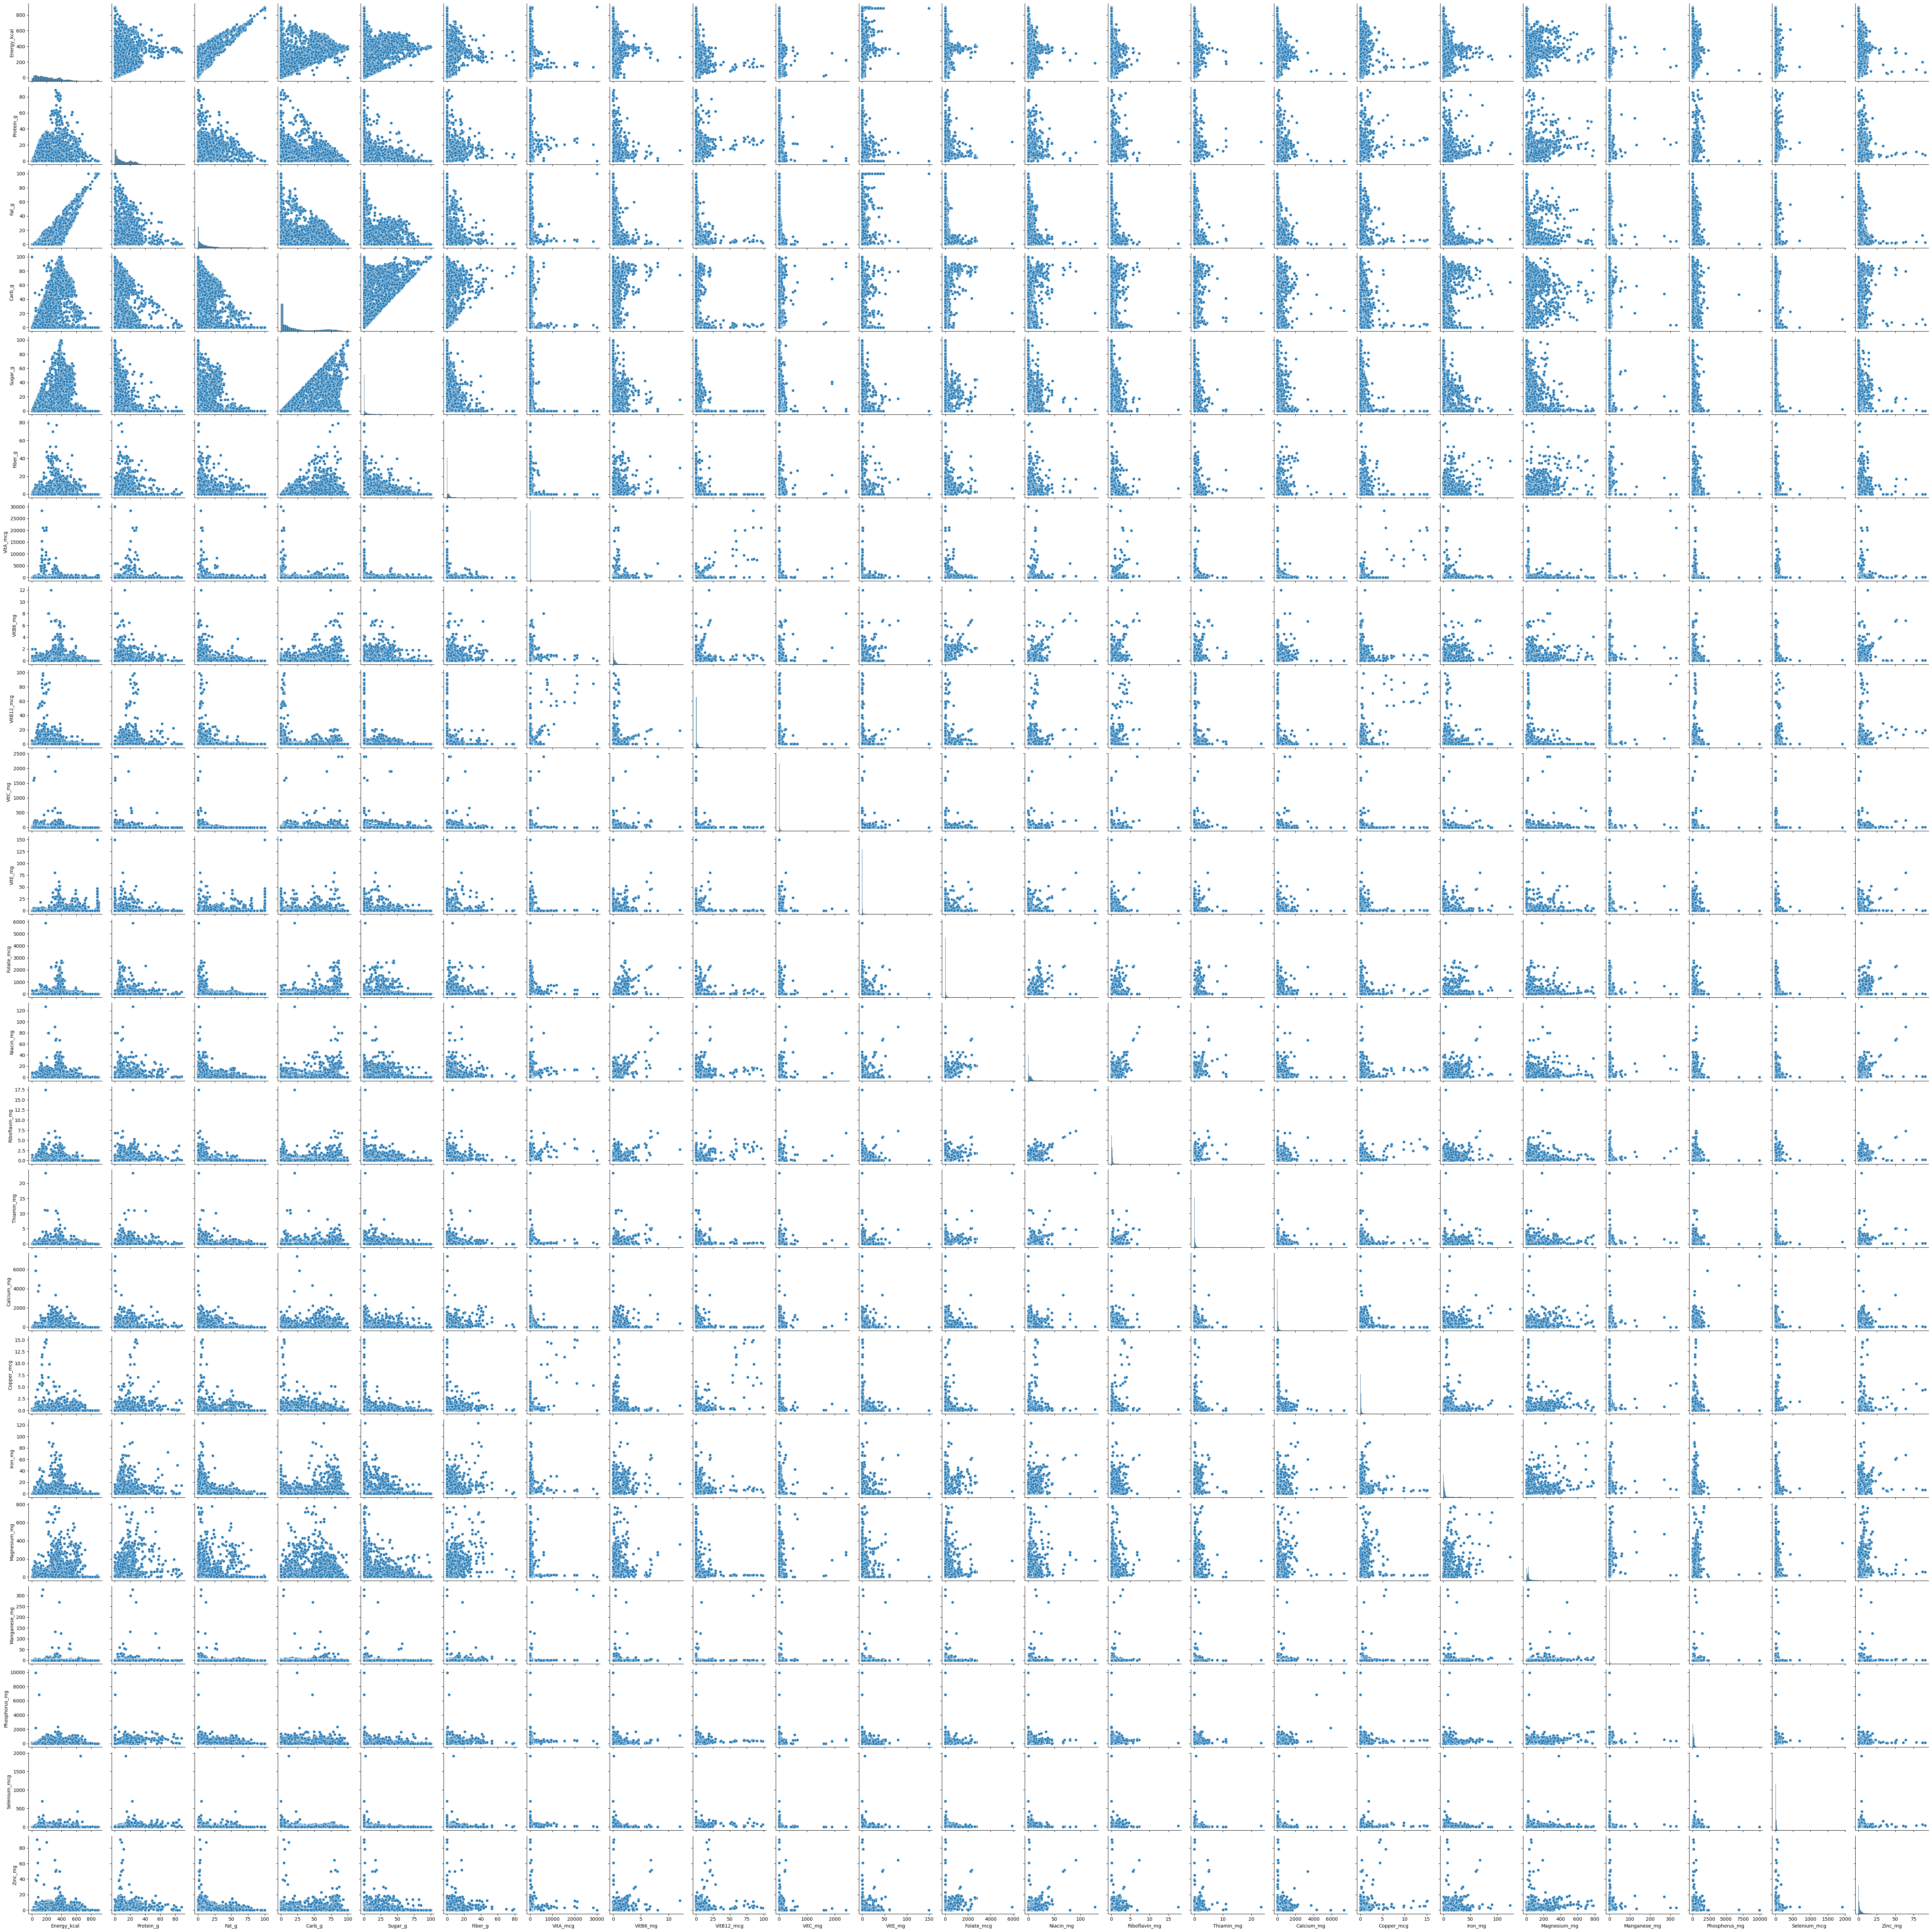

In [22]:
# Se aplica .iloc[:, 7:] porque las primeras 7 columnas (ID, FoodGroup, Descrip, etc.) 
# son etiquetas de texto o identificadores que no sirven para cálculos estadísticos.
# Al recortar, nos quedamos solo con las variables numéricas (Energy_kcal en adelante)
# que son las que el pairplot puede comparar y graficar.
df = df.iloc[:, 7:].copy()

# Generamos el gráfico de relaciones para analizar correlaciones entre nutrientes
sns.pairplot(df)
plt.show()



### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

<Axes: >

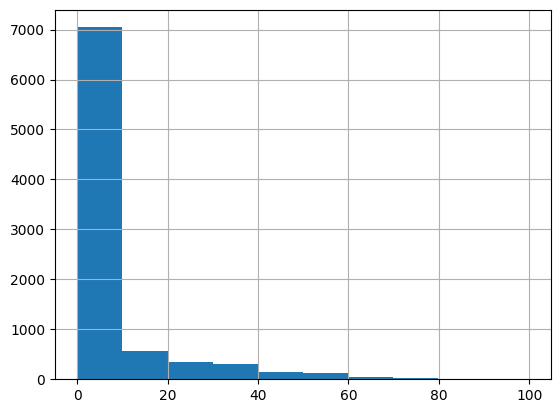

In [ ]:
# Accede a la columna 'Sugar_g' del DataFrame y genera un histograma
# .hist() agrupa los valores en rangos (bins) y cuenta cuántas veces aparece cada uno
# Esto sirve para ver la distribución de los azúcares en tus datos (frecuencia)
df['Sugar_g'].hist()


In [ ]:
from scipy import stats

# Calcula el coeficiente de asimetría (skewness) de la columna 'Energy_kcal'
# Un valor positivo indica que los datos se agrupan a la izquierda (cola larga a la derecha)
print(stats.skew(df['Energy_kcal']))

# Calcula el coeficiente de asimetría para 'Sugar_g'
# Sirve para entender si hay muchos alimentos con poco azúcar y algunos pocos con mucha cantidad
print(stats.skew(df['Sugar_g']))


-1.2118203825254381
1.0034222288460226


In [ ]:
# Intenta calcular el logaritmo natural de cero
# En matemáticas esto es indefinido, por lo que NumPy devolverá '-inf' (infinito negativo)
# y lanzará un aviso (RuntimeWarning) de división por cero.
np.log(0)


C:\Users\Eneko\AppData\Local\Temp\ipykernel_24264\2933082444.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


np.float64(-inf)

In [ ]:
# Se suma 1 al valor (0) antes de calcular el logaritmo para evitar el error de log(0).
# Esta técnica se llama "log1p" y se usa en estadística para transformar datos que 
# contienen ceros, asegurando que el resultado sea 0 (log(1) = 0) en lugar de -inf.
np.log(0 + 1)

np.float64(0.0)

In [ ]:
# Calcula el logaritmo natural de (1 + x). 
# Es equivalente a hacer np.log(0 + 1), pero es más preciso y eficiente.
# Se usa para transformar datos sesgados que contienen ceros sin generar errores.
np.log1p(0)

np.float64(0.0)

In [ ]:
# Recorre cada una de las columnas presentes en el DataFrame 'df'
for col in df.columns:
    # Aplica la transformación logarítmica log(1 + x) a todos los valores de la columna.
    # Esto se hace para normalizar distribuciones muy asimétricas y reducir el impacto
    # de los valores extremos (outliers), manejando los ceros de forma segura.
    df[col] = np.log1p(df[col])

<Axes: >

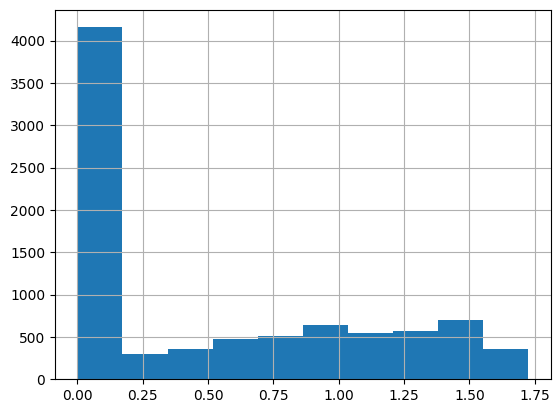

In [ ]:
# Genera el histograma de 'Sugar_g' tras haber aplicado la transformación logarítmica
# Ahora la distribución debería verse menos "comprimida" y más balanceada,
# ya que el logaritmo reduce la distancia entre los valores pequeños y los muy grandes.
df['Sugar_g'].hist()


### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [ ]:
# Crea una instancia del escalador para normalizar los datos
# StandardScaler resta la media y divide por la desviación estándar (Z-score)
scaler = StandardScaler()

# Ajusta el escalador con los datos del DataFrame y los transforma
# Esto convierte los datos para que tengan media 0 y varianza 1, 
# haciendo que todas las columnas sean comparables entre sí
df_scaled = scaler.fit_transform(df)

# Muestra el resultado, que ahora es un array de NumPy con los valores escalados
df_scaled

array([[ 1.17453529, -1.3523462 ,  1.5930863 , ..., -0.21832242,
        -0.48734362, -1.16546852],
       [ 1.17453529, -1.3523462 ,  1.5930863 , ..., -0.23624058,
        -0.48734362, -1.25942662],
       [ 1.30327108, -1.96952253,  1.66889328, ..., -1.2684192 ,
        -1.35267968, -1.36065018],
       ...,
       [ 0.4917456 , -2.49562522, -1.89786984, ..., -0.72931382,
        -0.6531688 , -0.95701315],
       [-0.39799564,  0.71216759, -0.59724163, ...,  0.60899047,
         1.06187417,  0.02531599],
       [-0.40791077,  0.83082898, -1.1939078 , ...,  0.49068624,
         0.8750049 ,  0.02531599]], shape=(8618, 23))

In [ ]:
# Calcula la longitud (número de elementos) del primer registro en el array X_pca
# En el contexto de un PCA, este valor indica cuántos Componentes Principales 
# se han generado tras la reducción de dimensionalidad
len(X_pca[0])

23

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [ ]:
# Devuelve una tupla que representa las dimensiones del objeto df_scaled
# El primer número indica la cantidad de filas (muestras)
# El segundo número indica la cantidad de columnas (características/nutrientes)
df_scaled.shape

(8618, 23)

In [ ]:
# Crea el modelo PCA configurado para reducir los datos a 23 componentes principales
pca = PCA(n_components=23)

# Ajusta el modelo con los datos escalados y aplica la reducción de dimensionalidad
# Transforma las variables originales en un nuevo conjunto de variables (componentes)
X_pca = pca.fit_transform(df_scaled)

# Muestra el array resultante con las coordenadas de los datos en el nuevo espacio de 23 dimensiones
X_pca

array([[-2.13285772, -1.47872564, -0.13662983, ..., -0.34987076,
        -1.02858941, -0.32318287],
       [-2.0670934 , -1.37972481, -0.07622499, ..., -0.49372745,
        -1.05403847, -0.27613888],
       [-3.82196941, -1.88163394,  1.1374345 , ..., -0.15584657,
        -1.00678912, -0.8414562 ],
       ...,
       [-3.20172785,  0.98586401,  1.11820203, ..., -0.31336293,
        -0.59628227,  0.2672806 ],
       [ 1.32190229, -0.57416681, -1.49019002, ..., -0.20125524,
         0.67916661,  0.79848427],
       [ 0.91687027, -1.32335498, -2.10579277, ..., -0.16705785,
        -0.63704598,  0.22738484]], shape=(8618, 23))

### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

In [ ]:
# Calcula la suma acumulada de la varianza explicada por cada componente principal.
# El resultado es un array donde cada valor indica qué porcentaje de la información 
# total (varianza) del dataset original capturan los primeros 'n' componentes.
# Por ejemplo, si el último valor es 0.95, significa que tus 23 componentes retienen el 95% de la información.
pca.explained_variance_ratio_.cumsum()


array([0.32381018, 0.48729002, 0.57512907, 0.63988796, 0.69828918,
       0.74318413, 0.77293853, 0.79946488, 0.8235257 , 0.84730724,
       0.87013894, 0.88847296, 0.90545408, 0.91951895, 0.93266157,
       0.94424096, 0.95534308, 0.96509995, 0.97369292, 0.98163978,
       0.98823313, 0.99447499, 1.        ])

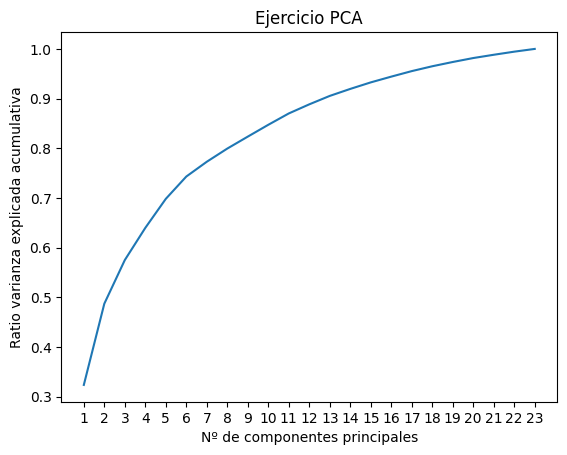

In [ ]:
# Genera un gráfico de línea usando la varianza acumulada como eje Y
# Se crea una Serie de Pandas para asignar los índices del 1 al 23 en el eje X
plt.plot(pd.Series(pca.explained_variance_ratio_.cumsum(), index=np.arange(1, 24)))

# Define la etiqueta del eje X (número de componentes)
plt.xlabel("Nº de componentes principales")

# Define la etiqueta del eje Y (proporción de información total retenida)
plt.ylabel("Ratio varianza explicada acumulativa")

# Añade un título descriptivo al gráfico
plt.title("Ejercicio PCA")

# Fuerza a que el eje X muestre todas las marcas del 1 al 23 para mejorar la lectura
plt.xticks(np.arange(1, 24))

# El punto y coma final evita que se imprima el objeto del gráfico en el notebook
plt.show()

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [ ]:
# Crea una nueva instancia de PCA configurada para reducir los datos a solo 6 componentes
pca6 = PCA(n_components=6)

# Ajusta el modelo y transforma los datos escalados al nuevo espacio de 6 dimensiones
# Esto simplifica significativamente el dataset original manteniendo los ejes de mayor información
X_pca6 = pca6.fit_transform(df_scaled)

In [ ]:
# Convierte el array resultante del PCA (X_pca6) en un DataFrame de Pandas
# Se asignan nombres descriptivos a las columnas ('PC1' a 'PC6') para facilitar su manejo
df_pca6 = pd.DataFrame(X_pca6, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'])

# Muestra el DataFrame resultante con los 6 componentes principales para cada registro
df_pca6


,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.132858,-1.478726,-0.136630,-1.002384,3.756908,0.602972
1,-2.067093,-1.379725,-0.076225,-1.026111,3.680115,0.656707
2,-3.821969,-1.881634,1.137434,-0.311557,3.813031,1.702231
3,1.593327,-1.297963,-1.039551,-0.605828,1.954047,-1.446671
4,1.165341,-1.222032,-1.062625,-0.969459,2.171133,-1.660302
...,...,...,...,...,...,...
8613,2.669732,-2.350600,-1.177254,-0.077560,2.488152,0.513880
8614,0.271258,-1.697508,-1.531053,-0.865871,-0.388078,-0.947058
8615,-3.201728,0.985864,1.118202,0.385917,-0.535378,-1.047394
8616,1.321902,-0.574167,-1.490190,-1.108449,1.524833,1.348070


In [ ]:
# Crea un DataFrame que muestra la "carga" o influencia de cada variable original en los 6 componentes
# pca6.components_ contiene los coeficientes (pesos) de la combinación lineal de las variables
# columns=df.columns asigna los nombres de los nutrientes originales a las columnas
# index=['PC1', 'PC2'...] etiqueta las filas según el componente principal correspondiente
df_pca_origin = pd.DataFrame(pca6.components_, columns=df.columns, index=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'])

# Muestra la matriz de componentes para identificar qué nutrientes definen cada PC
df_pca_origin


,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
PC1,0.183006,0.293104,0.181272,-0.059334,-0.063696,0.019103,0.075865,0.259596,0.225635,-0.047336,...,0.259327,0.214394,0.157879,0.187285,0.274904,0.265919,0.117953,0.281460,0.264595,0.314497
PC2,0.006459,-0.153351,-0.155995,0.441721,0.320731,0.411931,0.099674,-0.007567,-0.258086,0.268684,...,0.066208,0.173528,0.187848,0.191302,0.114658,0.129026,0.319424,0.025875,-0.150447,-0.118396
PC3,0.421046,0.077515,0.359676,0.181244,0.218243,0.181111,-0.330938,-0.012251,-0.083349,-0.308076,...,0.098475,0.242790,-0.235121,-0.067570,0.163033,-0.213763,-0.024052,-0.148881,-0.166247,-0.026926
PC4,-0.180375,-0.146101,-0.187467,-0.022087,0.191688,-0.050941,0.168843,0.372232,0.270771,0.323300,...,0.386163,0.298403,-0.129017,-0.235550,0.070936,-0.183276,-0.304572,-0.160976,-0.156846,-0.034077
PC5,0.266000,-0.067988,0.352936,0.005464,0.240163,-0.123589,0.484179,-0.072027,0.067353,0.047493,...,-0.032472,-0.148526,0.116431,-0.121332,-0.175460,-0.055289,-0.163135,0.008811,0.108123,-0.068656
PC6,-0.094592,-0.180528,-0.005263,-0.213139,-0.222548,-0.040673,-0.141586,0.177379,0.029451,0.079801,...,-0.001870,0.010581,-0.352454,0.431663,0.007834,-0.180405,0.335096,-0.308409,0.008895,0.077899


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [ ]:
# Carga de nuevo el dataset original completo desde el archivo CSV
# Esto recupera todas las columnas descriptivas (como nombres y grupos de alimentos)
# que se perdieron durante el proceso de limpieza y transformación anterior.
df_last = pd.read_csv("data/nndb_flat.csv")

# Muestra el contenido del DataFrame cargado para verificar que los datos son correctos
df_last


,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,83110,Finfish and Shellfish Products,"MACKEREL,SALTED","Fish, mackerel, salted",NaN,NaN,NaN,305.0,18.50,25.10,...,0.0375,0.206250,0.146154,0.016667,0.055000,0.000111,0.142857,0.362857,1.334545,0.100000
8614,90240,Finfish and Shellfish Products,"SCALLOP,(BAY&SEA),CKD,STMD","Mollusks, scallop, (bay and sea), cooked, steamed",NaN,NaN,NaN,111.0,20.54,0.84,...,0.0500,0.067250,0.018462,0.010000,0.008333,0.000037,0.088095,0.608571,0.394545,0.140909
8615,90480,Sweets,"SYRUP,CANE","Syrup, Cane",NaN,NaN,NaN,269.0,0.00,0.00,...,0.0000,0.006250,0.046154,0.108333,0.010833,0.000022,0.023810,0.011429,0.012727,0.017273
8616,90560,Finfish and Shellfish Products,"SNAIL,RAW","Mollusks, snail, raw",NaN,NaN,NaN,90.0,16.10,1.40,...,0.0150,0.087500,0.092308,0.008333,0.008333,0.000444,0.595238,0.388571,0.498182,0.090909


In [ ]:
# Crea una nueva columna 'FoodGroup' en el DataFrame de los componentes principales
# Se copian los valores desde el DataFrame original (df_last) para poder 
# etiquetar cada punto del PCA con su categoría de alimento correspondiente.
df_pca6['FoodGroup'] = df_last['FoodGroup'].copy()


In [ ]:
# Agrupa los datos por la columna 'FoodGroup' y calcula el promedio para cada componente principal
# Luego, ordena los grupos resultantes de menor a mayor basándose en los valores del primer componente (PC1)
# Esto sirve para identificar qué categorías de alimentos tienen las puntuaciones más altas o bajas en ese eje
df_pca6.groupby("FoodGroup").mean().sort_values(by=['PC1'])


,PC1,PC2,PC3,PC4,PC5,PC6
FoodGroup,,,,,,
Beverages,-3.869075,-0.013923,-0.690691,0.928396,-0.712797,0.803294
Fats and Oils,-3.862623,-1.411986,1.686550,-0.302977,2.638701,2.192209
"Soups, Sauces, and Gravies",-3.318215,-0.116477,0.145229,0.060185,-0.238731,0.182773
Fruits and Fruit Juices,-3.013920,1.598011,-0.972960,0.463449,-0.077434,-0.138438
Sweets,-2.168549,0.878161,0.728460,-0.530360,0.582067,-0.435614
Vegetables and Vegetable Products,-1.464213,1.710874,-1.740556,0.256154,-0.454637,0.100518
American Indian/Alaska Native Foods,-0.943073,-0.881720,0.483642,-0.043932,-0.366708,0.238952
"Meals, Entrees, and Side Dishes",-0.909009,0.760562,0.436906,-0.200687,0.311914,-0.555655
Baby Foods,-0.736104,1.182636,-0.913553,0.702532,0.987555,-0.178956


In [ ]:
# Genera un resumen estadístico descriptivo de todas las columnas numéricas del DataFrame original
# Proporciona medidas como el conteo de datos (count), la media (mean), la desviación estándar (std),
# los valores mínimo y máximo, y los percentiles (25%, 50%, 75%).
df_last.describe()


,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
count,8618.000000,8618.000000,8618.00000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,15467.757368,226.438617,11.52391,10.647024,21.819062,6.560253,2.023242,93.968786,0.264369,1.225260,...,0.125765,0.213222,0.182499,0.174881,0.061176,0.000191,0.077965,0.222838,0.229363,0.179111
std,9221.428766,169.388910,10.55059,15.866353,27.239000,13.602098,4.313670,779.362205,0.478614,4.319183,...,0.466402,0.302161,0.346062,0.431974,0.167803,0.000615,0.133496,0.290133,0.514406,0.305292
min,1001.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8695.250000,93.000000,2.47000,0.992500,0.040000,0.000000,0.000000,0.000000,0.034250,0.000000,...,0.000000,0.023875,0.035385,0.025000,0.007500,0.000033,0.023810,0.052857,0.001818,0.020909
50%,14273.000000,191.000000,8.28500,5.235000,8.945000,0.370000,0.300000,1.500000,0.120000,0.080000,...,0.017500,0.131250,0.115385,0.064583,0.015833,0.000088,0.047619,0.190000,0.070909,0.076818
75%,20050.750000,336.000000,19.97750,13.900000,32.900000,5.300000,2.400000,21.000000,0.355000,1.297500,...,0.062500,0.314328,0.200000,0.185833,0.051667,0.000161,0.069048,0.308571,0.387273,0.245455
max,93600.000000,902.000000,88.32000,100.000000,100.000000,99.800000,79.000000,30000.000000,12.000000,98.890000,...,14.702500,7.968750,13.461538,19.479167,6.136667,0.016722,1.859524,14.168571,34.854545,8.268182
